[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/AASHIR/hw1-4/HW1.4/HW1_4_svd_pca.ipynb)

# homework 1.4: SVD, low-rank approximation, and PCA

**name:** Aashir  
**course:** MAT 422, Fall 2026  
**topics:** singular value decomposition, low-rank matrix approximations, and principal component analysis

We'll use the same small matrix for SVD and low-rank approximation, so it's easier to see how the two ideas connect. Then we'll try PCA on two related quiz scores and see how much of their variation we can keep with just one component.

## setup

We only need NumPy for the calculations and Matplotlib for the plots. Both are already available in Colab, so there's nothing extra to install. The cells are meant to run from top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 4.5), "font.size": 11})

## 1.4.1 singular value decomposition

SVD lets us split a real matrix into three parts:

$$A=U\Sigma V^T.$$

The columns of $U$ and $V$ are the singular vectors. Within each matrix, these columns have length 1 and are perpendicular to one another, which is what orthonormal means. The diagonal of $\Sigma$ holds the nonnegative singular values, from largest to smallest. Applying $A$ to an input direction $v_i$ gives $\sigma_i u_i$, so $Av_i=\sigma_i u_i$.

I picked a $4\times3$ matrix to show that SVD works on a rectangular matrix too. Using reduced SVD gives a $4\times3$ matrix $U$, a $3\times3$ matrix $\Sigma$, and a $3\times3$ matrix $V^T$. NumPy returns $V^T$ rather than $V$, so I called that result `Vt` in the code.

After finding those pieces, we multiply them back together and check whether we get $A$ back. The other checks test the orthonormal columns and $Av_i=\sigma_i u_i$.

In [2]:
A = np.array([
    [3.0, 1.0, 1.0],
    [1.0, 3.0, 1.0],
    [1.0, 1.0, 3.0],
    [1.0, 0.0, 1.0],
])

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
reconstructed = U @ Sigma @ Vt
reconstruction_error = np.linalg.norm(A - reconstructed, "fro")

print("A =\n", A)
print("U =\n", U)
print("singular values =", s)
print("V transpose =\n", Vt)
print("shapes:", U.shape, Sigma.shape, Vt.shape)
print("U.T @ U =\n", U.T @ U)
print("Vt @ Vt.T =\n", Vt @ Vt.T)
print("reconstructed A =\n", reconstructed)
print(f"reconstruction error = {reconstruction_error:.2e}")
print("rank of A =", np.linalg.matrix_rank(A))

assert np.allclose(reconstructed, A)
assert np.allclose(U.T @ U, np.eye(3))
assert np.allclose(Vt @ Vt.T, np.eye(3))
assert np.allclose(A @ Vt.T, U @ Sigma)
assert np.all(s >= 0) and np.all(np.diff(s) <= 0)
assert np.linalg.matrix_rank(A) == 3

A =
 [[3. 1. 1.]
 [1. 3. 1.]
 [1. 1. 3.]
 [1. 0. 1.]]
U =
 [[-0.5685 -0.321  -0.7071]
 [-0.5478  0.8168  0.    ]
 [-0.5685 -0.321   0.7071]
 [-0.2315 -0.356  -0.    ]]
singular values = [5.1356 2.1507 2.    ]
V transpose =
 [[-0.5945 -0.5414 -0.5945]
 [-0.3828  0.8408 -0.3828]
 [-0.7071  0.      0.7071]]
shapes: (4, 3) (3, 3) (3, 3)
U.T @ U =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
Vt @ Vt.T =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
reconstructed A =
 [[3. 1. 1.]
 [1. 3. 1.]
 [1. 1. 3.]
 [1. 0. 1.]]
reconstruction error = 3.59e-15
rank of A = 3


We get singular values of about $5.1356$, $2.1507$, and $2.0000$. None is zero, so the matrix has rank 3. The reconstructed matrix matches the original apart from a tiny floating-point error. Both orthogonality checks also give the identity up to rounding. One detail worth keeping straight: since $U$ is rectangular, the check is $U^TU=I_3$, not $UU^T=I_4$.

If the singular vectors come out with different signs on another system, that doesn't necessarily mean something is wrong. Flipping matching signs in $U$ and $V$ leaves their product unchanged. In the plot, the first singular value stands out, but the other two are still large enough that we shouldn't expect to drop them without much error.

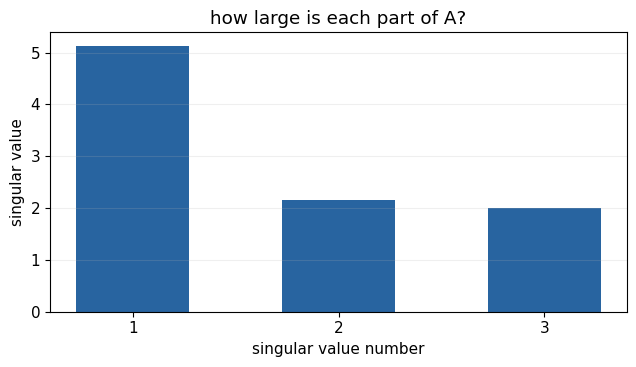

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar([1, 2, 3], s, color="#2864a0", width=0.55)
ax.set(xlabel="singular value number", ylabel="singular value",
       title="how large is each part of A?")
ax.set_xticks([1, 2, 3])
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## 1.4.2 low-rank matrix approximations

Another way to look at SVD is to write $A$ as a sum of smaller pieces, each with rank 1. Here, $r$ is the rank of $A$:

$$A=\sum_{i=1}^{r}\sigma_i u_i v_i^T.$$

What if we keep just the first $k$ pieces? That gives us

$$A_k=U_k\Sigma_kV_k^T.$$

This isn't just one possible way to reduce the rank. The Eckart-Young theorem says it gives a best approximation of rank at most $k$ when we measure error with the Frobenius norm. That norm squares all the entries, adds them, and takes the square root. For truncated SVD, we can also find the error directly from the singular values we leave out:

$$\|A-A_k\|_F=\sqrt{\sum_{i=k+1}^{r}\sigma_i^2}.$$

Below, we try keeping one, two, and then all three pieces of the same matrix. The retained percentage tells us how much of $\|A\|_F^2$ we kept. It doesn't mean that the same percentage of matrix entries is exactly right.

In [4]:
ranks = [1, 2, 3]
approximations = []
errors = []
tail_errors = []
retained = []

print(" k   actual rank   error       discarded-value error   retained")
for k in ranks:
    # this time, we're only keeping the first k pieces
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    error = np.linalg.norm(A - A_k, "fro")
    tail_error = np.sqrt(np.sum(s[k:] ** 2))
    kept = np.sum(s[:k] ** 2) / np.sum(s ** 2)

    approximations.append(A_k)
    errors.append(error)
    tail_errors.append(tail_error)
    retained.append(kept)
    print(f" {k}       {np.linalg.matrix_rank(A_k)}       {error:.6f}"
          f"          {tail_error:.6f}            {100 * kept:.2f}%")

    assert np.linalg.matrix_rank(A_k) == k
    assert np.isclose(error, tail_error)

print("\nrank-1 approximation =\n", approximations[0])
print("\nrank-2 approximation =\n", approximations[1])

assert np.allclose(approximations[0], s[0] * np.outer(U[:, 0], Vt[0]))
assert np.allclose(approximations[-1], A)
assert np.all(np.diff(errors) <= 1e-12)

 k   actual rank   error       discarded-value error   retained
 1       1       2.936957          2.936957            75.36%
 2       2       2.000000          2.000000            88.57%
 3       3       0.000000          0.000000            100.00%

rank-1 approximation =
 [[1.7357 1.5805 1.7357]
 [1.6725 1.523  1.6725]
 [1.7357 1.5805 1.7357]
 [0.7069 0.6437 0.7069]]

rank-2 approximation =
 [[2. 1. 2.]
 [1. 3. 1.]
 [2. 1. 2.]
 [1. 0. 1.]]


Keeping just one piece gives an error of about $2.9370$. Keeping two lowers it to $2.0000$, and keeping all three brings it close to zero. Rank 1 keeps about 75.36% of the squared Frobenius norm, compared with about 88.57% for rank 2. So even with two components, we haven't quite recovered the original matrix.

The two error calculations agree, which is what the formula predicted. The plot makes the tradeoff pretty clear: keeping more components lowers the error, but we give up some of the rank reduction. This matrix is too small to claim a useful storage saving. For a larger matrix, storing the smaller factors can help if they contain fewer entries than the original.

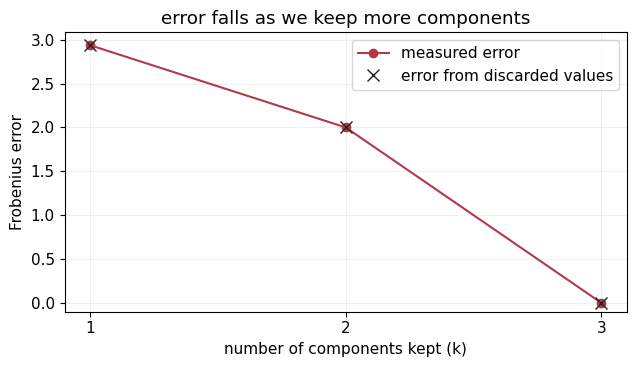

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(ranks, errors, "o-", color="#b23a48", label="measured error")
ax.plot(ranks, tail_errors, "x", color="#222222", markersize=9,
        label="error from discarded values")
ax.set(xlabel="number of components kept (k)", ylabel="Frobenius error",
       title="error falls as we keep more components")
ax.set_xticks(ranks)
ax.set_ylim(bottom=-0.1)
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 1.4.3 principal component analysis

PCA looks for the directions where the data spreads out the most. The first principal component follows the direction with the largest variance. The second captures the most remaining variance while staying perpendicular to the first.

For this example, each row is a made-up student's scores on two quizzes, both out of 10. Higher scores on one quiz usually go with higher scores on the other, so it seems reasonable to try describing most of that variation with one direction. These are just example values, not real student records.

Before applying SVD, we subtract each column's mean. That way, we're looking at how the scores vary around their average, not how far they sit from zero. I kept the original scales here because both quizzes use the same units and have similar spreads. If the columns had very different units or scales, we'd need to think about standardizing them too.

In [6]:
X = np.array([
    [2.0, 1.0],
    [3.0, 2.0],
    [4.0, 2.0],
    [5.0, 4.0],
    [6.0, 4.0],
    [7.0, 5.0],
    [8.0, 6.0],
    [9.0, 6.0],
])

means = X.mean(axis=0)
X_centered = X - means

print("quiz scores =\n", X)
print("column means =", means)
print("centered scores =\n", X_centered)
print("means after centering =", X_centered.mean(axis=0))

assert np.allclose(X_centered.mean(axis=0), 0)

quiz scores =
 [[2. 1.]
 [3. 2.]
 [4. 2.]
 [5. 4.]
 [6. 4.]
 [7. 5.]
 [8. 6.]
 [9. 6.]]
column means = [5.5  3.75]
centered scores =
 [[-3.5  -2.75]
 [-2.5  -1.75]
 [-1.5  -1.75]
 [-0.5   0.25]
 [ 0.5   0.25]
 [ 1.5   1.25]
 [ 2.5   2.25]
 [ 3.5   2.25]]
means after centering = [0. 0.]


The averages are $5.50$ and $3.75$. After subtracting them, both columns have mean zero, as expected. Now we can apply SVD to the centered matrix:

$$X_c=U_p\Sigma_pV_p^T,\qquad T=X_cV_p.$$

The columns of $V_p$ tell us the principal directions. Multiplying by them gives $T$, which holds each student's coordinates along those directions. Since we have $n=8$ rows, the sample variance of component $i$ is $s_i^2/(n-1)$. Dividing each component's variance by the total tells us its share of the variance, called the explained variance ratio.

This ties back to eigenvectors from homework 1.2. The principal directions are eigenvectors of the covariance matrix $C=X_c^TX_c/(n-1)$. We check that in the code too, so we can see the connection instead of just calling a PCA function.

In [7]:
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
directions = Vt_pca.T
scores = X_centered @ directions

variance = s_pca ** 2 / (len(X) - 1)
variance_ratio = variance / variance.sum()
covariance = X_centered.T @ X_centered / (len(X) - 1)
score_covariance = scores.T @ scores / (len(X) - 1)

print("principal directions (one per column) =\n", directions)
print("PC1 and PC2 coordinates =\n", scores)
print("variance by component =", variance)
print("explained variance ratios =", variance_ratio)
print("covariance in the original coordinates =\n", covariance)
print("covariance in PC coordinates =\n", score_covariance)

assert np.allclose(directions.T @ directions, np.eye(2))
assert np.allclose(scores, U_pca @ np.diag(s_pca))
assert np.allclose(covariance @ directions, directions @ np.diag(variance))
assert np.allclose(score_covariance, np.diag(variance))
assert np.isclose(variance_ratio.sum(), 1)
assert np.allclose(scores @ directions.T, X_centered)

principal directions (one per column) =
 [[ 0.7905  0.6125]
 [ 0.6125 -0.7905]]
PC1 and PC2 coordinates =
 [[-4.451   0.03  ]
 [-3.048  -0.148 ]
 [-2.2576  0.4645]
 [-0.2421 -0.5039]
 [ 0.5484  0.1086]
 [ 1.9513 -0.0693]
 [ 3.3543 -0.2472]
 [ 4.1448  0.3653]]
variance by component = [9.5423 0.1005]
explained variance ratios = [0.9896 0.0104]
covariance in the original coordinates =
 [[6.     4.5714]
 [4.5714 3.6429]]
covariance in PC coordinates =
 [[ 9.5423 -0.    ]
 [-0.      0.1005]]


PC1 accounts for about 98.96% of the variance, leaving about 1.04% for PC2. That's a large share for just one component. A PC1 direction is approximately $(0.7905,0.6125)^T$. Both entries have the same sign, which makes sense because the two quiz scores tend to rise together. Pointing the whole vector the other way would still give the same axis.

The covariance matrix in PC coordinates is diagonal, so the two component scores are uncorrelated. On the left, we can see the centered scores and the two principal directions. Each arrow is one standard deviation long along its component. On the right, the same points are shown using PC1 and PC2 as the axes. We haven't thrown anything away yet, since both components are still there.

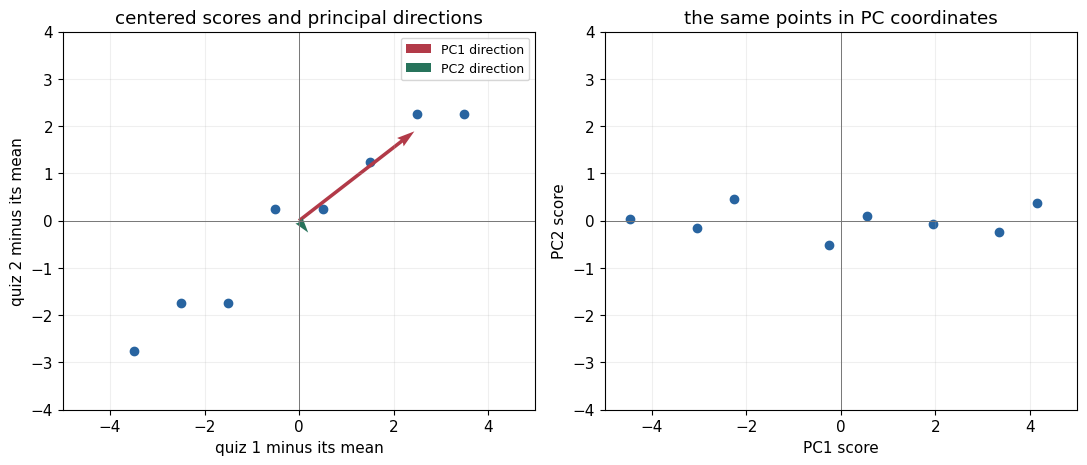

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], color="#2864a0")

colors = ["#b23a48", "#27735b"]
for i in range(2):
    arrow = directions[:, i] * np.sqrt(variance[i])
    axes[0].quiver(0, 0, arrow[0], arrow[1], angles="xy", scale_units="xy",
                   scale=1, color=colors[i], label=f"PC{i + 1} direction")

axes[0].set(xlabel="quiz 1 minus its mean", ylabel="quiz 2 minus its mean",
            title="centered scores and principal directions")
axes[0].legend(fontsize=9)

axes[1].scatter(scores[:, 0], scores[:, 1], color="#2864a0")
axes[1].set(xlabel="PC1 score", ylabel="PC2 score",
            title="the same points in PC coordinates")

for ax in axes:
    ax.axhline(0, color="#777777", linewidth=0.7)
    ax.axvline(0, color="#777777", linewidth=0.7)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-4, 4)
    ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

### keeping only PC1

Now we actually reduce the data by keeping only the PC1 scores. That leaves one number per student instead of two. To see how close this gets us to the original scores, we multiply by the first direction to project onto the PC1 line, then add the means back:

$$\widehat X_c=T_{:,1}v_1^T,\qquad \widehat X=\widehat X_c+\mathbf{1}\mu^T.$$

The **centered** approximation has rank 1. Once we add the means back, the reconstructed matrix doesn't have to have rank 1, so it's important not to mix those two up. Based on the earlier low-rank formula, the error should equal the second singular value that we're dropping.

In [9]:
# :1 keeps this as a column, which we need for the matrix multiplication
pc1_scores = scores[:, :1]
projected_centered = pc1_scores @ directions[:, :1].T
X_approx = projected_centered + means
pca_residual = X_centered - projected_centered
pca_error = np.linalg.norm(pca_residual, "fro")

print("one PC1 score per student =", pc1_scores.ravel())
print("scores reconstructed using PC1 =\n", X_approx)
print(f"variance kept = {100 * variance_ratio[0]:.2f}%")
print(f"reconstruction error = {pca_error:.6f}")
print(f"discarded singular value = {s_pca[1]:.6f}")

assert np.linalg.matrix_rank(projected_centered) == 1
assert np.isclose(pca_error, s_pca[1])
assert np.allclose(pca_residual @ directions[:, 0], 0)
assert np.allclose(X_approx.mean(axis=0), means)

one PC1 score per student = [-4.451  -3.048  -2.2576 -0.2421  0.5484  1.9513  3.3543  4.1448]
scores reconstructed using PC1 =
 [[1.9817 1.0237]
 [3.0906 1.883 ]
 [3.7155 2.3672]
 [5.3086 3.6017]
 [5.9335 4.0859]
 [7.0424 4.9452]
 [8.1514 5.8046]
 [8.7763 6.2887]]
variance kept = 98.96%
reconstruction error = 0.838827
discarded singular value = 0.838827


With one component, we keep about 98.96% of the sample variance and get a Frobenius reconstruction error of about $0.8388$. That matches the second singular value, just as expected. The residuals are also perpendicular to PC1, so the points really are being projected onto that line.

In the plot, the reconstructed scores sit on one line, and the short gray segments show what we lose by dropping PC2. The loss is small for these closely related scores. That doesn't mean a low-variance direction is always safe to ignore, though; it could still matter for a different task.

This is also different from the regression example in homework 1.3. We aren't choosing one quiz as the response and predicting it from the other. PCA minimizes the sum of squared perpendicular distances to the line, rather than the vertical errors used in that regression example.

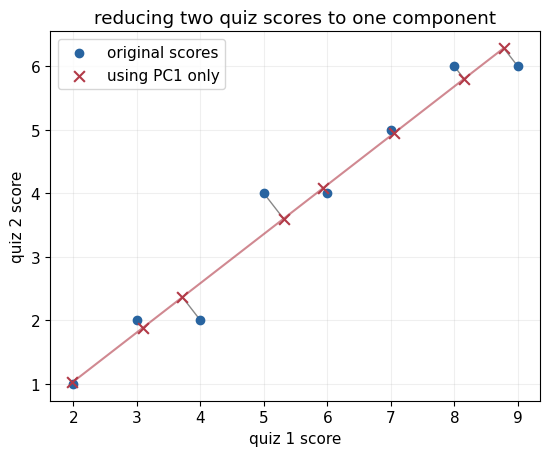

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.7))
ax.scatter(X[:, 0], X[:, 1], color="#2864a0", label="original scores", zorder=3)
ax.scatter(X_approx[:, 0], X_approx[:, 1], color="#b23a48", marker="x",
           s=60, label="using PC1 only", zorder=4)

# connect each original point to where it lands on the PC1 line
for original, projected in zip(X, X_approx):
    ax.plot([original[0], projected[0]], [original[1], projected[1]],
            color="#888888", linewidth=1)

order = np.argsort(X_approx[:, 0])
ax.plot(X_approx[order, 0], X_approx[order, 1], color="#b23a48", alpha=0.6)
ax.set(xlabel="quiz 1 score", ylabel="quiz 2 score",
       title="reducing two quiz scores to one component")
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## final checks

Here's one last check of the main results. If the notebook has run from the top, every line below should say `True`.

In [11]:
checks = {
    "SVD reconstructs A": np.allclose(reconstructed, A),
    "singular vectors are orthonormal": np.allclose(U.T @ U, np.eye(3))
                                      and np.allclose(Vt @ Vt.T, np.eye(3)),
    "low-rank errors match the formula": np.allclose(errors, tail_errors),
    "keeping all three terms recovers A": np.allclose(approximations[-1], A),
    "PCA data is centered": np.allclose(X_centered.mean(axis=0), 0),
    "PC scores are uncorrelated": np.allclose(score_covariance, np.diag(variance)),
    "variance ratios sum to one": np.isclose(variance_ratio.sum(), 1),
    "PC1 error matches the discarded singular value": np.isclose(pca_error, s_pca[1]),
}

for name, passed in checks.items():
    print(f"{name}: {passed}")

assert all(checks.values())

SVD reconstructs A: True
singular vectors are orthonormal: True
low-rank errors match the formula: True
keeping all three terms recovers A: True
PCA data is centered: True
PC scores are uncorrelated: True
variance ratios sum to one: True
PC1 error matches the discarded singular value: True


## conclusion

The main thing I took from these examples is that reducing the rank doesn't work equally well for every matrix. Our first matrix needed all three terms to come back exactly, and dropping even one left a noticeable error. The quiz scores were different: because the two columns varied together so closely, one principal component kept nearly all their variance. We used SVD in both cases, but the singular values showed how much we could afford to leave out. The projection plot helped make that concrete because we could see exactly where the reconstructed scores missed the original points.

## before submitting

- Run every cell from the top and check that the final results are all `True`.
- Review the examples, comments, and conclusions, and make sure they match your own understanding.
- Check that the equations, outputs, and plot labels are readable in the published notebook.
- Complete the required Colab/GitHub publishing step and check the Open in Colab badge before submitting the notebook URL.

## notes and references

- MAT 422 [section 1.4 guidance](https://github.com/DynamicLLM/MAT422/blob/main/Skills/Student-Home-Work-Skills-Pack/mat422-section-1-4-svd-pca/references/section-1-4-guidance.md).
- NumPy documentation: [singular value decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) and [matrix norms](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).
- The quiz scores are made-up values for this example. Matplotlib was used for the plots.

- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.